Installing libraries...
Checking GPU...
GPU Available ✅
Loading YOLOv8 model...
Weapon Classes: ['knife', 'scissors', 'baseball bat', 'gun', 'bomb']

Upload Image


Saving Screenshot 2026-05-18 at 5.13.23 PM.png to Screenshot 2026-05-18 at 5.13.23 PM (5).png

Running Face Detection...
Faces Detected: 0

Running YOLO Detection...

FINAL RESULT

Decision:
Rejected ❌

Reasons:
-  Image is blurry. Blur score: 76.82
-  No human face detected.

Detected Objects:
-  person (0.32)

Face Count: 0


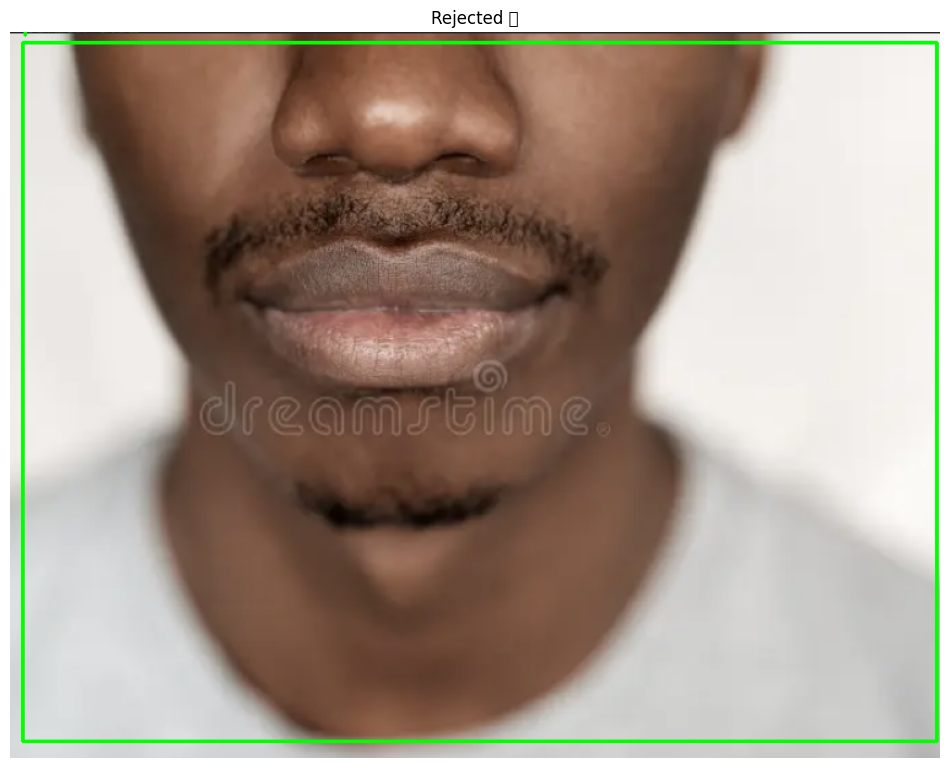


FUTURE IMPROVEMENTS

1. Replace proxy weapon detection with custom weapon dataset
2. Add liveness detection
3. Add mask detection
4. Add age detection
5. Add emotion detection
6. Add NSFW detection
7. Convert into FastAPI backend
8. Connect Angular frontend
9. Store face embeddings in database
10. Real-time webcam support



In [ ]:
# ============================================================
# MODERN AI IMAGE APPROVAL SYSTEM
# ============================================================
#
# FEATURES
# --------
# ✅ Modern Face Detection using RetinaFace
# ✅ YOLOv8 Object Detection
# ✅ Weapon Detection
# ✅ Blur Detection
# ✅ Dark Image Detection
# ✅ Multiple Face Detection
# ✅ Optional Face Verification (same person check)
# ✅ Clean Visualization
# ✅ Production-style Rule Engine
#
# WORKFLOW
# --------
# Upload Image
#      ↓
# Image Quality Check
#      ↓
# Face Detection (RetinaFace)
#      ↓
# YOLO Object Detection
#      ↓
# Face Verification (Optional)
#      ↓
# Apply Rules
#      ↓
# Approved / Rejected
#
# ============================================================

# ============================================================
# STEP 1 — INSTALL LIBRARIES
# ============================================================

print("Installing libraries...")

!pip install -q ultralytics deepface retina-face opencv-python-headless matplotlib

# ============================================================
# STEP 2 — IMPORT LIBRARIES
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from ultralytics import YOLO
from retinaface import RetinaFace
from deepface import DeepFace
import torch
import os

# ============================================================
# STEP 3 — DEVICE CHECK
# ============================================================

print("Checking GPU...")

if torch.cuda.is_available():
    device = "cuda"
    print("GPU Available ✅")
else:
    device = "cpu"
    print("Using CPU ⚠️")

# ============================================================
# STEP 4 — LOAD YOLO MODEL
# ============================================================

print("Loading YOLOv8 model...")

model = YOLO("yolov8n.pt")

class_names = model.names

# ============================================================
# STEP 5 — DEFINE WEAPON CLASSES
# ============================================================

# COCO dataset does not have guns
# These are proxy unsafe objects

weapon_names = [
    "knife",
    "scissors",
    "baseball bat",
    "gun",
    "bomb"
]

weapon_class_ids = []

for class_id, name in class_names.items():
    if name in weapon_names:
        weapon_class_ids.append(class_id)

print("Weapon Classes:", weapon_names)

# ============================================================
# STEP 6 — IMAGE QUALITY CHECKS
# ============================================================

def is_blurry(image, threshold=100):

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    variance = cv2.Laplacian(gray, cv2.CV_64F).var()

    return variance < threshold, variance


def is_dark(image, threshold=50):

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    brightness = np.mean(gray)

    return brightness < threshold, brightness

# ============================================================
# STEP 7 — FACE DETECTION USING RETINAFACE
# ============================================================

def detect_faces(image):

    faces = RetinaFace.detect_faces(image)

    if isinstance(faces, dict):
        return faces
    else:
        return {}

# ============================================================
# STEP 8 — OPTIONAL FACE VERIFICATION
# ============================================================

def verify_faces(reference_path, uploaded_path):

    try:

        result = DeepFace.verify(
            img1_path=reference_path,
            img2_path=uploaded_path,
            enforce_detection=False
        )

        return result["verified"]

    except Exception as e:

        print("Verification Error:", e)

        return False

# ============================================================
# STEP 9 — UPLOAD IMAGE
# ============================================================

print("\nUpload Image")

uploaded = files.upload()

if len(uploaded) == 0:
    raise Exception("No image uploaded")

uploaded_filename = list(uploaded.keys())[0]

# ============================================================
# STEP 10 — READ IMAGE
# ============================================================

image_bgr = cv2.imread(uploaded_filename)

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

annotated = image_rgb.copy()

# ============================================================
# STEP 11 — IMAGE QUALITY CHECK
# ============================================================

reasons = []

decision = "Approved ✅"

# Resolution Check
height, width = image_rgb.shape[:2]

if width < 200 or height < 200:
    decision = "Rejected ❌"
    reasons.append("Image resolution too low.")

# Blur Check
blur_status, blur_score = is_blurry(image_rgb)

if blur_status:
    decision = "Rejected ❌"
    reasons.append(f"Image is blurry. Blur score: {blur_score:.2f}")

# Brightness Check
dark_status, brightness = is_dark(image_rgb)

if dark_status:
    decision = "Rejected ❌"
    reasons.append(f"Image too dark. Brightness: {brightness:.2f}")

# ============================================================
# STEP 12 — FACE DETECTION
# ============================================================

print("\nRunning Face Detection...")

faces = detect_faces(image_rgb)

face_count = len(faces)

print("Faces Detected:", face_count)

# Draw Faces
for key in faces:

    facial_area = faces[key]["facial_area"]

    x1, y1, x2, y2 = facial_area

    cv2.rectangle(
        annotated,
        (x1, y1),
        (x2, y2),
        (255, 255, 0),
        2
    )

    cv2.putText(
        annotated,
        "Face",
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 255, 0),
        2
    )

# ============================================================
# STEP 13 — FACE RULES
# ============================================================

if face_count == 0:
    decision = "Rejected ❌"
    reasons.append("No human face detected.")

elif face_count > 1:
    decision = "Rejected ❌"
    reasons.append(f"Multiple faces detected ({face_count}).")

# ============================================================
# STEP 14 — YOLO OBJECT DETECTION
# ============================================================

print("\nRunning YOLO Detection...")

results = model.predict(
    source=image_rgb,
    conf=0.25,
    iou=0.5,
    device=device,
    verbose=False
)

weapon_detected = False

detected_objects = []

# ============================================================
# STEP 15 — PROCESS YOLO RESULTS
# ============================================================

for result in results:

    boxes = result.boxes

    for box in boxes:

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        confidence = float(box.conf[0])

        class_id = int(box.cls[0])

        class_name = class_names[class_id]

        detected_objects.append(
            f"{class_name} ({confidence:.2f})"
        )

        color = (0, 255, 0)

        # Weapon Detection
        if class_id in weapon_class_ids:

            weapon_detected = True

            color = (255, 0, 0)

        cv2.rectangle(
            annotated,
            (x1, y1),
            (x2, y2),
            color,
            2
        )

        cv2.putText(
            annotated,
            f"{class_name} {confidence:.2f}",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            2
        )

# ============================================================
# STEP 16 — WEAPON RULE
# ============================================================

if weapon_detected:
    decision = "Rejected ❌"
    reasons.append("Weapon / unsafe object detected.")

# ============================================================
# STEP 17 — OPTIONAL FACE VERIFICATION
# ============================================================

# ============================================================
# HOW TO USE
# ============================================================
#
# Uncomment below if you want same-person verification
#
# Example:
#
# reference.jpg -> original stored user image
# uploaded.jpg  -> newly uploaded image
#
# ============================================================

"""
same_person = verify_faces(
    reference_path="reference.jpg",
    uploaded_path=uploaded_filename
)

if not same_person:
    decision = "Rejected ❌"
    reasons.append("Face verification failed.")
"""

# ============================================================
# STEP 18 — FINAL APPROVAL
# ============================================================

if decision == "Approved ✅":

    reasons.append("Exactly one clear face detected.")
    reasons.append("No unsafe object found.")
    reasons.append("Image quality acceptable.")

# ============================================================
# STEP 19 — DISPLAY RESULTS
# ============================================================

print("\n================================================")
print("FINAL RESULT")
print("================================================")

print("\nDecision:")
print(decision)

print("\nReasons:")

for reason in reasons:
    print("- ", reason)

print("\nDetected Objects:")

if len(detected_objects) == 0:
    print("- No objects detected")
else:
    for obj in detected_objects:
        print("- ", obj)

print("\nFace Count:", face_count)

# ============================================================
# STEP 20 — SHOW IMAGE
# ============================================================

plt.figure(figsize=(12, 10))

plt.imshow(annotated)

plt.title(decision)

plt.axis("off")

plt.show()

# ============================================================
# STEP 21 — PROJECT IMPROVEMENTS
# ============================================================

print("\n================================================")
print("FUTURE IMPROVEMENTS")
print("================================================")

print("""
1. Replace proxy weapon detection with custom weapon dataset
2. Add liveness detection
3. Add mask detection
4. Add age detection
5. Add emotion detection
6. Add NSFW detection
7. Convert into FastAPI backend
8. Connect Angular frontend
9. Store face embeddings in database
10. Real-time webcam support
""")

# ============================================================
# END
# ============================================================



Upload Image for Processing


Saving Screenshot 2026-05-18 at 5.08.16 PM.png to Screenshot 2026-05-18 at 5.08.16 PM (1).png
Uploaded file: Screenshot 2026-05-18 at 5.08.16 PM (1).png

Running Face Detection...
Faces Detected: 0

Running YOLO Detection...

FINAL RESULT from method call

Decision:
Rejected ❌

Reasons:
- No human face detected.

Detected Objects:
- person (0.88)
- tie (0.75)

Face Count: 0


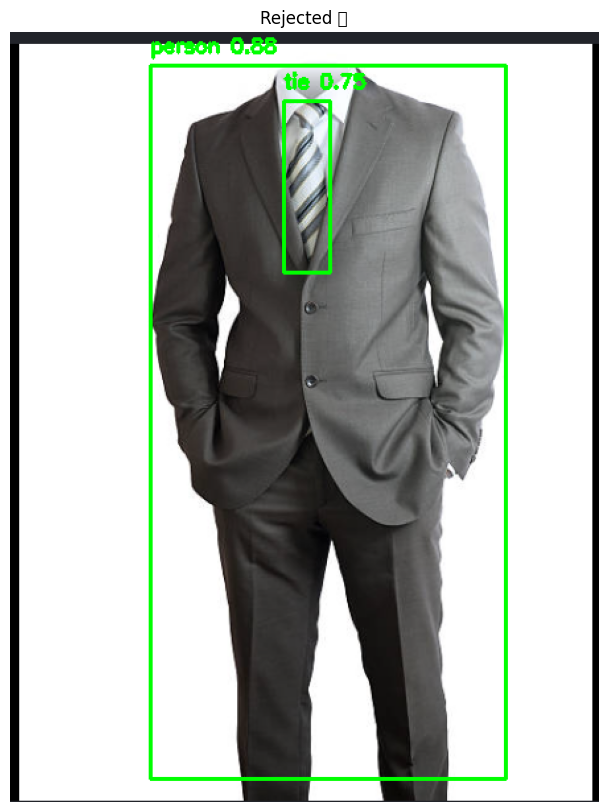

In [ ]:
def process_image_for_approval():
    """
    Uploads an image, processes it for approval based on defined rules,
    and returns the decision, reasons, detected objects, the annotated image,
    and the number of faces detected.
    """
    # STEP 9 — UPLOAD IMAGE
    print("\nUpload Image for Processing")
    uploaded = files.upload()

    if len(uploaded) == 0:
        print("No image uploaded. Aborting processing.")
        return "Not Processed", ["No image uploaded."], [], None, 0

    uploaded_filename = list(uploaded.keys())[0]
    print(f"Uploaded file: {uploaded_filename}")

    # STEP 10 — READ IMAGE
    image_bgr = cv2.imread(uploaded_filename)
    if image_bgr is None:
        print(f"Error reading image: {uploaded_filename}")
        return "Rejected \u274C", ["Error reading image file."], [], None, 0

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    annotated = image_rgb.copy()

    # Initialize results
    reasons = []
    decision = "Approved \u2705"
    detected_objects = []
    face_count = 0

    # STEP 11 — IMAGE QUALITY CHECK
    height, width = image_rgb.shape[:2]
    if width < 200 or height < 200:
        decision = "Rejected \u274C"
        reasons.append("Image resolution too low.")

    blur_status, blur_score = is_blurry(image_rgb)
    if blur_status:
        decision = "Rejected \u274C" # Optimized: Directly set to Rejected
        reasons.append(f"Image is blurry. Blur score: {blur_score:.2f}")

    dark_status, brightness = is_dark(image_rgb)
    if dark_status:
        decision = "Rejected \u274C" # Optimized: Directly set to Rejected
        reasons.append(f"Image too dark. Brightness: {brightness:.2f}")

    # STEP 12 — FACE DETECTION
    print("\nRunning Face Detection...")
    faces = detect_faces(image_rgb)
    face_count = len(faces)
    print("Faces Detected:", face_count)

    # Draw Faces
    for key in faces:
        facial_area = faces[key]["facial_area"]
        x1, y1, x2, y2 = facial_area
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (255, 255, 0), 2)
        cv2.putText(annotated, "Face", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)

    # STEP 13 — FACE RULES
    if face_count == 0:
        decision = "Rejected \u274C" # Optimized: Directly set to Rejected
        reasons.append("No human face detected.")
    elif face_count > 1:
        decision = "Rejected \u274C" # Optimized: Directly set to Rejected
        reasons.append(f"Multiple faces detected ({face_count}).")

    # STEP 14 — YOLO OBJECT DETECTION
    print("\nRunning YOLO Detection...")
    results = model.predict(source=image_rgb, conf=0.25, iou=0.5, device=device, verbose=False)
    weapon_detected = False

    # STEP 15 — PROCESS YOLO RESULTS
    for result in results:
        boxes = result.boxes
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            confidence = float(box.conf[0])
            class_id = int(box.cls[0])
            class_name = class_names[class_id]
            detected_objects.append(f"{class_name} ({confidence:.2f})")

            color = (0, 255, 0)
            if class_id in weapon_class_ids:
                weapon_detected = True
                color = (255, 0, 0)

            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
            cv2.putText(annotated, f"{class_name} {confidence:.2f}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    # STEP 16 — WEAPON RULE
    if weapon_detected:
        decision = "Rejected \u274C" # Optimized: Directly set to Rejected
        reasons.append("Weapon / unsafe object detected.")

    # STEP 18 — FINAL APPROVAL (add generic approval reasons if still approved)
    if decision == "Approved \u2705":
        if "Exactly one clear face detected." not in reasons and face_count == 1:
            reasons.append("Exactly one clear face detected.")
        if "No unsafe object found." not in reasons and not weapon_detected:
            reasons.append("No unsafe object found.")
        if "Image quality acceptable." not in reasons and not blur_status and not dark_status and not (width < 200 or height < 200):
            reasons.append("Image quality acceptable.")

    return decision, reasons, detected_objects, annotated, face_count

# Example of how to call the new method and get the response
decision, reasons, detected_objects, annotated_image, face_count_result = process_image_for_approval()

if decision != "Not Processed":
    print("\n================================================")
    print("FINAL RESULT from method call")
    print("================================================")
    print("\nDecision:")
    print(decision)
    print("\nReasons:")
    for reason in reasons:
        print("-", reason)
    print("\nDetected Objects:")
    if len(detected_objects) == 0:
        print("- No objects detected")
    else:
        for obj in detected_objects:
            print("-", obj)
    print("\nFace Count:", face_count_result)

    if annotated_image is not None:
        plt.figure(figsize=(12, 10))
        plt.imshow(annotated_image)
        plt.title(decision)
        plt.axis("off")
        plt.show()


In [ ]:
# ============================================================
# CUSTOM YOLOv8 GUN DETECTION TRAINING AND INFERENCE
# ============================================================
# This notebook provides a complete workflow for training a custom YOLOv8
# model for gun detection using a custom dataset and then performing
# inference on test images.

# ============================================================
# 1. SETUP AND INSTALL LIBRARIES
# ============================================================

print("1. Installing Libraries...")
!pip install -q ultralytics
!pip install -q opencv-python-headless
!pip install -q matplotlib

import os
import zipfile
import shutil
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files
import torch

print("Libraries installed and imported successfully.\n")

# ============================================================
# 2. GPU CHECK
# ============================================================

if torch.cuda.is_available():
    DEVICE = "cuda"
    print("GPU Available ✅ - Training will use GPU.")
else:
    DEVICE = "cpu"
    print("GPU Not Available ⚠️ - Training will use CPU. This might be slower.")
print(f"Using device: {DEVICE}\n")

# ============================================================
# 3. DATASET PREPARATION
# ============================================================

def upload_and_unzip_dataset(zip_file_name="archive.zip", extract_path="dataset"):
    """
    Uploads a ZIP file, unzips it, and verifies its structure.
    Handles nested directories within the zip file.
    """
    print(f"3.1. Attempting to locate/upload dataset ZIP file: {zip_file_name} ...")

    # Check if the file already exists in /content/
    if os.path.exists(os.path.join('/content/', zip_file_name)):
        print(f"'{zip_file_name}' found locally. Skipping upload.")
    else:
        uploaded = files.upload()
        if not uploaded:
            print("Error: No file uploaded. Please upload your dataset zip file.")
            return False

        if zip_file_name not in uploaded:
            print(f"Error: Expected file '{zip_file_name}' not found. Found: {list(uploaded.keys())}")
            return False

        # Save the uploaded file
        with open(zip_file_name, 'wb') as f:
            f.write(uploaded[zip_file_name])
        print(f"'{zip_file_name}' uploaded successfully.")

    # Create a temporary extraction directory
    temp_extract_path = "./temp_dataset_extract"
    if os.path.exists(temp_extract_path):
        shutil.rmtree(temp_extract_path)
    os.makedirs(temp_extract_path, exist_ok=True)

    # Unzip the dataset to the temporary path
    print(f"3.2. Unzipping '{zip_file_name}' to '{temp_extract_path}' ...")
    try:
        with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
            zip_ref.extractall(temp_extract_path)
        print("Dataset unzipped successfully to temporary location.")

        # Determine the effective root of the dataset within the temporary extraction path
        actual_dataset_root = None
        for root_dir, dirs, files_in_dir in os.walk(temp_extract_path):
            # Check if this directory (root_dir) contains the YOLOv8 structure
            has_train = 'train' in dirs
            has_valid = 'valid' in dirs
            has_data_yaml = 'data.yaml' in files_in_dir

            # Also check for the required sub-directories (images/labels within train/valid)
            has_train_images = os.path.isdir(os.path.join(root_dir, 'train', 'images'))
            has_train_labels = os.path.isdir(os.path.join(root_dir, 'train', 'labels'))
            has_valid_images = os.path.isdir(os.path.join(root_dir, 'valid', 'images'))
            has_valid_labels = os.path.isdir(os.path.join(root_dir, 'valid', 'labels'))

            if has_data_yaml and has_train and has_valid and has_train_images and has_train_labels and has_valid_images and has_valid_labels:
                actual_dataset_root = root_dir
                break

        if actual_dataset_root is None:
            print(f"Error: Could not find dataset structure (train/images, train/labels, valid/images, valid/labels, data.yaml) within '{zip_file_name}'.")
            shutil.rmtree(temp_extract_path)
            return False

        print(f"Identified actual dataset root: {actual_dataset_root}")

        # Clean up existing target directory if it exists
        if os.path.exists(extract_path):
            shutil.rmtree(extract_path)
        os.makedirs(extract_path, exist_ok=True) # Ensure target path exists

        # Move contents from actual_dataset_root to the target extract_path
        print(f"Moving contents from '{actual_dataset_root}' to '{extract_path}'...")
        for item in os.listdir(actual_dataset_root):
            shutil.move(os.path.join(actual_dataset_root, item), extract_path)

        shutil.rmtree(temp_extract_path) # Clean up the entire temporary extraction parent directory
        print("Dataset contents moved to target location successfully.\n")
        return True

    except zipfile.BadZipFile:
        print(f"Error: '{zip_file_name}' is a bad zip file. It might be corrupted or not a zip.")
        if os.path.exists(temp_extract_path):
            shutil.rmtree(temp_extract_path)
        return False
    except Exception as e:
        print(f"Error unzipping or moving file: {e}")
        if os.path.exists(temp_extract_path):
            shutil.rmtree(temp_extract_path)
        return False


def verify_dataset_structure(dataset_path="dataset"):
    """
    Verifies the expected YOLOv8 dataset structure.
    Expected: dataset/train/images, dataset/train/labels, dataset/valid/images, dataset/valid/labels, dataset/data.yaml
    """
    print(f"3.3. Verifying dataset structure at '{dataset_path}' ...")
    required_dirs = [
        os.path.join(dataset_path, 'train', 'images'),
        os.path.join(dataset_path, 'train', 'labels'),
        os.path.join(dataset_path, 'valid', 'images'),
        os.path.join(dataset_path, 'valid', 'labels')
    ]
    required_file = os.path.join(dataset_path, 'data.yaml')

    for d in required_dirs:
        if not os.path.isdir(d):
            print(f"Error: Missing directory '{d}'. Please check your dataset structure.")
            return False

    if not os.path.isfile(required_file):
        print(f"Error: Missing data.yaml file at '{required_file}'.")
        return False

    print("Dataset structure verified successfully.")

    # Optionally, read and print data.yaml content
    try:
        with open(required_file, 'r') as f:
            data_yaml = yaml.safe_load(f)
        print("data.yaml content:")
        for key, value in data_yaml.items():
            print(f"  {key}: {value}")
        return True
    except Exception as e:
        print(f"Error reading data.yaml: {e}")
        return False


# Call dataset preparation functions. Using 'archive (1).zip' as per user's mention.
if upload_and_unzip_dataset("archive (1).zip", "custom_gun_dataset"):
    if not verify_dataset_structure("custom_gun_dataset"):
        print("Dataset verification failed. Please correct your dataset structure.")
        exit() # Exit if dataset is not correctly structured
else:
    print("Dataset upload failed. Exiting.")
    exit()

# ============================================================
# 4. TRAIN CUSTOM YOLOv8 MODEL
# ============================================================

def train_yolov8_model(data_yaml_path, epochs=50, imgsz=640, batch_size=16, base_model="yolov8n.pt"):
    """
    Trains a custom YOLOv8 model.
    """
    print("\n4.1. Loading base YOLOv8 model...")
    # Load a pretrained YOLOv8n model
    model = YOLO(base_model)

    print(f"4.2. Starting training with parameters: epochs={epochs}, imgsz={imgsz}, batch={batch_size}...")
    # Train the model using the custom dataset
    results = model.train(
        data=data_yaml_path,
        epochs=epochs,
        imgsz=imgsz, # Fixed typo from imgz to imgsz
        batch=batch_size,
        device=DEVICE,
        name="yolov8_gun_detection"
    )

    print("Model training completed.\n")
    return results


# Define the path to your data.yaml file
data_config_path = os.path.join("custom_gun_dataset", "data.yaml")

best_model_path = None # Initialize best_model_path

# Train the model
try:
    training_results = train_yolov8_model(
        data_config_path,
        epochs=50,
        imgsz=640,
        batch_size=16
    )
    best_model_path = os.path.join(training_results.save_dir, 'weights', 'best.pt')
    print(f"Best model saved at: {best_model_path}\n")
except Exception as e:
    print(f"Error during model training: {e}")
    # Do not exit here, allow the user to still attempt inference if best_model_path is manually set or exists from previous run


# ============================================================
# 5. INFERENCE FUNCTIONS
# ============================================================

def run_inference(model_path, test_image_path, confidence_threshold=0.25):
    """
    Loads the trained model and performs inference on a test image.
    """
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found at: {model_path}")

    print(f"5.1. Loading best model from: {model_path} ...")
    model = YOLO(model_path)

    print(f"5.2. Running inference on '{test_image_path}' ...")
    # Run inference
    results = model.predict(
        source=test_image_path,
        conf=confidence_threshold,
        device=DEVICE,
        imgsz=640,
        save=True, # Save annotated image
        project='inference_results', # Save results to a folder
        name='gun_detection_inference' # Name for the inference run
    )

    return results, model.names


def display_inference_results(results, class_names, test_image_path):
    """
    Displays detected objects and the processed image.
    """
    print("\n5.3. Displaying Inference Results...")
    detected_weapons = []
    annotated_image_path = None

    for r in results:
        # Get the path to the saved annotated image
        if r.path: # r.path is the original image path
            # Ultralytics saves results in runs/detect/name/image.jpg
            output_dir = os.path.join(r.save_dir, os.path.basename(test_image_path))
            if os.path.exists(output_dir):
                annotated_image_path = output_dir

        for box in r.boxes:
            class_id = int(box.cls[0])
            confidence = float(box.conf[0])
            class_name = class_names[class_id]
            detected_weapons.append(f"{class_name} (Confidence: {confidence:.2f})")

    print("Detected objects:")
    if detected_weapons:
        for weapon in detected_weapons:
            print(f"- {weapon}")
    else:
        print("- No weapons detected.")

    if annotated_image_path and os.path.exists(annotated_image_path):
        img_bgr = cv2.imread(annotated_image_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 8))
        plt.imshow(img_rgb)
        plt.title("Inference Result (Gun Detection)")
        plt.axis('off')
        plt.show()
    else:
        print("Could not find the annotated image to display.")


def perform_gun_detection_inference_on_uploaded_image(model_path):
    """
    Uploads a test image, runs gun detection inference, and displays the results.
    Assumes a trained YOLO model is available at model_path.
    """
    if model_path is None or not os.path.exists(model_path):
        print("Error: Trained model not found. Please ensure training completed successfully or provide a valid model_path.")
        return

    print("\n--- Starting Gun Detection Inference Workflow ---")
    print("Please upload a test image for gun detection.")

    uploaded_test_image = files.upload()

    if not uploaded_test_image:
        print("No test image uploaded. Aborting inference.")
        return

    test_image_filename = list(uploaded_test_image.keys())[0]
    print(f"Test image '{test_image_filename}' uploaded successfully.\n")

    try:
        inference_results, class_names_map = run_inference(model_path, test_image_filename)
        display_inference_results(inference_results, class_names_map, test_image_filename)
    except Exception as e:
        print(f"Error during inference: {e}")

    print("--- Gun Detection Inference Workflow Completed ---\n")


# ============================================================
# 6. RUN INFERENCE (after training)
# ============================================================

if best_model_path:
    perform_gun_detection_inference_on_uploaded_image(best_model_path)
else:
    print("Skipping inference on uploaded image because model training was not successful.")


# ============================================================
# 7. OPTIONAL: VIDEO / WEBCAM INFERENCE
# ============================================================

print("\n\n================================================")
print("7. OPTIONAL: VIDEO / WEBCAM INFERENCE")
print("================================================")
print("This section provides placeholders or basic examples for video/webcam inference.")

# --- Video Inference Example ---
# To run video inference, you would first need to upload a video file.
# For example:
# uploaded_video = files.upload()
# if uploaded_video:
#     video_filename = list(uploaded_video.keys())[0]
#     print(f"Running inference on video: {video_filename}")
#     model = YOLO(best_model_path)
#     results = model.predict(
#         source=video_filename,
#         conf=0.25,
#         device=DEVICE,
#         save=True, # Saves annotated video
#         project='inference_results',
#         name='video_gun_detection'
#     )
#     print("Video inference complete. Output video saved in 'runs/detect/video_gun_detection/'.")
# else:
#     print("No video uploaded for inference.")

# --- Webcam Inference Placeholder ---
# Real-time webcam inference in Google Colab requires more complex setup
# involving JavaScript bridges or tools like ngrok for local execution.
# A direct and simple Python implementation for live webcam feed isn't feasible
# directly within the Colab environment without significant workarounds.
print("\nWebcam inference is generally complex in Colab. Consider local execution or cloud VMs for real-time applications.")

print("\nOptional sections concluded.")

# ============================================================
# END OF WORKFLOW
# ============================================================


1. Installing Libraries...
Libraries installed and imported successfully.

GPU Available ✅ - Training will use GPU.
Using device: cuda

3.1. Attempting to locate/upload dataset ZIP file: archive (1).zip ...
'archive (1).zip' found locally. Skipping upload.
3.2. Unzipping 'archive (1).zip' to './temp_dataset_extract' ...
Dataset unzipped successfully to temporary location.
Error: Could not find dataset structure (train/images, train/labels, valid/images, valid/labels, data.yaml) within 'archive (1).zip'.
Dataset upload failed. Exiting.

4.1. Loading base YOLOv8 model...
4.2. Starting training with parameters: epochs=50, imgsz=640, batch=16...
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, co

In [ ]:
# ============================================================
# CUSTOM YOLOv8 GUN/PISTOL DETECTION PIPELINE
# Dataset Conversion → Training → Inference
# ============================================================

# This notebook provides a complete pipeline to:
# 1. Automatically detect and convert various annotation formats (YOLO, Pascal VOC, COCO)
#    from a custom dataset (e.g., 'PistolData_merged').
# 2. Split the dataset into training and validation sets.
# 3. Create the standard YOLOv8 directory structure and `data.yaml`.
# 4. Train a YOLOv8n model on the prepared dataset.
# 5. Run inference on an uploaded image with the trained model.

# ============================================================
# 1. SETUP AND INSTALL LIBRARIES
# ============================================================

print("1. Installing Libraries...")
!pip install -q ultralytics
!pip install -q opencv-python-headless
!pip install -q matplotlib
!pip install -q xmltodict # For Pascal VOC XML parsing
!pip install -q scikit-learn # For train-test split

import os
import zipfile
import shutil
import json
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files
import torch
import xml.etree.ElementTree as ET # For Pascal VOC XML parsing
from sklearn.model_selection import train_test_split
import random

print("Libraries installed and imported successfully.\n")

# ============================================================
# 2. GPU CHECK
# ============================================================

if torch.cuda.is_available():
    DEVICE = "cuda"
    print("GPU Available ✅ - Training will use GPU.")
else:
    DEVICE = "cpu"
    print("GPU Not Available ❗ - Training will use CPU. This might be slower.")
print(f"Using device: {DEVICE}\n")

# ============================================================
# 3. DATASET PREPARATION & CONVERSION
# ============================================================

# Define the target class names and their mapping
CUSTOM_CLASS_NAMES = ['pistol', 'gun', 'weapon'] # User-defined class names
CLASS_NAME_TO_ID = {name: i for i, name in enumerate(CUSTOM_CLASS_NAMES)}

# Helper function to normalize bounding box coordinates
def convert_bbox_to_yolo(size, box):
    dw = 1. / size[0]
    dh = 1. / size[1]
    x = (box[0] + box[1]) / 2.0
    y = (box[2] + box[3]) / 2.0
    w = box[1] - box[0]
    h = box[3] - box[2]
    x = x * dw
    w = w * dw
    y = y * dh
    h = h * dh
    return (x, y, w, h)

# --- Annotation Parsers ---

def parse_yolo_annotation(annotation_path, image_width, image_height):
    """
    Parses a YOLO format .txt annotation file.
    Returns a list of (class_id, x_center, y_center, width, height) tuples.
    """
    annotations = []
    try:
        with open(annotation_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    # YOLO format is already normalized and has class_id
                    class_id = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:])
                    annotations.append((class_id, x_center, y_center, width, height))
    except Exception as e:
        print(f"Error parsing YOLO annotation {annotation_path}: {e}")
    return annotations

def parse_pascal_voc_annotation(annotation_path, class_name_to_id, image_width, image_height):
    """
    Parses a Pascal VOC format .xml annotation file.
    Returns a list of (class_id, x_center, y_center, width, height) tuples (YOLO format).
    """
    annotations = []
    try:
        tree = ET.parse(annotation_path)
        root = tree.getroot()

        for obj in root.findall('object'):
            obj_name = obj.find('name').text
            if obj_name not in class_name_to_id:
                # Attempt to map similar class names to 'gun' or 'pistol'
                if 'gun' in obj_name.lower() or 'pistol' in obj_name.lower() or 'weapon' in obj_name.lower():
                    obj_name = 'gun' # Default to 'gun' if a gun-like object is found
                else:
                    print(f"Warning: Unknown class '{obj_name}' in {annotation_path}. Skipping.")
                    continue

            class_id = class_name_to_id.get(obj_name)
            if class_id is None:
                # This case should ideally be caught by the above, but as a safeguard
                print(f"Error: Class '{obj_name}' not mapped to an ID. Check CUSTOM_CLASS_NAMES.")
                continue

            bbox = obj.find('bndbox')
            xmin = float(bbox.find('xmin').text)
            ymin = float(bbox.find('ymin').text)
            xmax = float(bbox.find('xmax').text)
            ymax = float(bbox.find('ymax').text)

            # Convert to YOLO format (normalized x_center, y_center, width, height)
            x_center = (xmin + xmax) / 2.0 / image_width
            y_center = (ymin + ymax) / 2.0 / image_height
            width = (xmax - xmin) / image_width
            height = (ymax - ymin) / image_height

            annotations.append((class_id, x_center, y_center, width, height))
    except Exception as e:
        print(f"Error parsing Pascal VOC annotation {annotation_path}: {e}")
    return annotations

def parse_coco_annotation(annotation_data, image_id, class_name_to_id, coco_categories, image_width, image_height):
    """
    Parses COCO format annotations for a specific image.
    Returns a list of (class_id, x_center, y_center, width, height) tuples (YOLO format).
    `annotation_data` is the entire parsed COCO JSON content.
    """
    annotations = []
    # Create a mapping from COCO category ID to its name
    coco_id_to_name = {cat['id']: cat['name'] for cat in coco_categories}

    for ann in annotation_data['annotations']:
        if ann['image_id'] == image_id:
            coco_category_id = ann['category_id']
            coco_class_name = coco_id_to_name.get(coco_category_id)

            if coco_class_name not in class_name_to_id:
                # Attempt to map similar class names
                if 'gun' in coco_class_name.lower() or 'pistol' in coco_class_name.lower() or 'weapon' in coco_class_name.lower():
                    coco_class_name = 'gun'
                else:
                    print(f"Warning: Unknown COCO class '{coco_class_name}'. Skipping annotation for image_id {image_id}.")
                    continue

            class_id = class_name_to_id.get(coco_class_name)
            if class_id is None:
                print(f"Error: Class '{coco_class_name}' not mapped to an ID. Check CUSTOM_CLASS_NAMES.")
                continue

            x, y, w, h = ann['bbox'] # COCO format: [x_min, y_min, width, height]

            # Convert to YOLO format (normalized x_center, y_center, width, height)
            x_center = (x + w / 2.0) / image_width
            y_center = (y + h / 2.0) / image_height
            width = w / image_width
            height = h / image_height

            annotations.append((class_id, x_center, y_center, width, height))
    return annotations


def detect_and_convert_annotation(image_path, annotation_path_base, image_filename, output_label_dir, class_name_to_id, coco_annotations=None, coco_categories=None):
    """
    Detects the annotation format and converts it to YOLOv8 format.
    Saves the converted annotation to output_label_dir.
    Returns True if conversion is successful, False otherwise.
    """
    base_name = os.path.splitext(image_filename)[0]
    output_label_path = os.path.join(output_label_dir, f"{base_name}.txt")

    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read image {image_path}. Skipping annotation conversion.")
        return False
    image_height, image_width, _ = img.shape

    converted_annotations = []
    found_format = None

    # Try YOLO format first (.txt)
    yolo_anno_path = os.path.join(annotation_path_base, f"{base_name}.txt")
    if os.path.exists(yolo_anno_path):
        converted_annotations = parse_yolo_annotation(yolo_anno_path, image_width, image_height)
        found_format = "YOLO"

    # Try Pascal VOC format (.xml)
    if not converted_annotations:
        voc_anno_path = os.path.join(annotation_path_base, f"{base_name}.xml")
        if os.path.exists(voc_anno_path):
            converted_annotations = parse_pascal_voc_annotation(voc_anno_path, class_name_to_id, image_width, image_height)
            found_format = "Pascal VOC"

    # Try COCO format (.json) - assumes a single JSON for all annotations
    if not converted_annotations and coco_annotations and coco_categories:
        # Find the image ID in coco_annotations
        image_id = None
        for img_info in coco_annotations['images']:
            if img_info['file_name'] == image_filename:
                image_id = img_info['id']
                break
        if image_id is not None:
            converted_annotations = parse_coco_annotation(coco_annotations, image_id, class_name_to_id, coco_categories, image_width, image_height)
            found_format = "COCO"

    if converted_annotations:
        with open(output_label_path, 'w') as f:
            for ann in converted_annotations:
                class_id, x_c, y_c, w, h = ann
                f.write(f"{class_id} {x_c:.6f} {y_c:.6f} {w:.6f} {h:.6f}\n")
        return True
    else:
        print(f"Warning: No annotation found or could not convert for {image_filename} using known formats.")
        return False

def prepare_yolov8_dataset(
    dataset_zip_path=None,
    extracted_dataset_dir="PistolData_merged",
    output_base_dir="dataset",
    train_ratio=0.8
):
    """
    Main function to prepare the dataset for YOLOv8 training.
    Handles unzipping, annotation conversion, and train/valid split.
    """
    print("\n--- Starting Dataset Preparation ---")

    if dataset_zip_path and not os.path.exists(extracted_dataset_dir):
        print(f"Unzipping {dataset_zip_path}...")
        with zipfile.ZipFile(dataset_zip_path, 'r') as zip_ref:
            zip_ref.extractall(".") # Extract in current directory
        print("Unzipping complete.")
    elif not os.path.exists(extracted_dataset_dir):
        print(f"Error: Dataset directory '{extracted_dataset_dir}' not found. Please upload '{dataset_zip_path}' or ensure the folder is present.")
        return False

    image_source_dir = os.path.join(extracted_dataset_dir, "pistol_images")
    annotation_source_dir = os.path.join(extracted_dataset_dir, "pistol_annotations")

    if not os.path.exists(image_source_dir) or not os.path.exists(annotation_source_dir):
        print(f"Error: Expected subdirectories 'pistol_images' and 'pistol_annotations' not found in '{extracted_dataset_dir}'.")
        print(f"Please ensure your dataset structure matches: {extracted_dataset_dir}/pistol_images/ and {extracted_dataset_dir}/pistol_annotations/")
        return False

    # Initialize COCO annotations if a JSON file exists
    coco_annotations = None
    coco_categories = None
    coco_json_path = os.path.join(annotation_source_dir, 'annotations.json') # Common COCO filename
    if os.path.exists(coco_json_path):
        try:
            with open(coco_json_path, 'r') as f:
                coco_annotations = json.load(f)
            coco_categories = coco_annotations.get('categories', [])
            print(f"Detected COCO annotation file: {coco_json_path}")
        except Exception as e:
            print(f"Error loading COCO annotations from {coco_json_path}: {e}")
            coco_annotations = None

    # Create target YOLOv8 directories
    output_train_images = os.path.join(output_base_dir, "train", "images")
    output_train_labels = os.path.join(output_base_dir, "train", "labels")
    output_valid_images = os.path.join(output_base_dir, "valid", "images")
    output_valid_labels = os.path.join(output_base_dir, "valid", "labels")

    # Clean up previous output directory if it exists
    if os.path.exists(output_base_dir):
        shutil.rmtree(output_base_dir)

    os.makedirs(output_train_images, exist_ok=True)
    os.makedirs(output_train_labels, exist_ok=True)
    os.makedirs(output_valid_images, exist_ok=True)
    os.makedirs(output_valid_labels, exist_ok=True)

    print(f"Created YOLOv8 dataset structure in '{output_base_dir}'.")

    image_files = [f for f in os.listdir(image_source_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if not image_files:
        print("Error: No image files found in 'pistol_images'.")
        return False

    processed_data = [] # List of (image_path, annotation_converted_successfully)
    total_images = len(image_files)
    converted_annotations_count = 0
    corrupt_files_count = 0
    current_image_filename = "" # Initialize for error handling

    print(f"Processing {total_images} images and their annotations...")
    for i, img_filename in enumerate(image_files):
        current_image_filename = img_filename # Store current filename for error reporting
        image_path = os.path.join(image_source_dir, img_filename)
        base_name = os.path.splitext(img_filename)[0]

        try:
            # Verify image integrity by trying to read it
            img = cv2.imread(image_path)
            if img is None:
                print(f"Corrupt or unreadable image: {image_path}. Skipping.")
                corrupt_files_count += 1
                continue

            # Convert annotation and save to a temporary location first
            temp_converted_label_path = os.path.join(output_base_dir, "temp_labels", f"{base_name}.txt")
            os.makedirs(os.path.dirname(temp_converted_label_path), exist_ok=True)

            # Pass the image path and base annotation directory, along with coco data if available
            converted_successfully = detect_and_convert_annotation(
                image_path,
                annotation_source_dir,
                img_filename,
                os.path.dirname(temp_converted_label_path),
                CLASS_NAME_TO_ID,
                coco_annotations,
                coco_categories
            )

            if converted_successfully:
                processed_data.append((image_path, temp_converted_label_path))
                converted_annotations_count += 1
            else:
                # If annotation not found or converted, still keep track of image for split but mark as no label
                processed_data.append((image_path, None))

        except Exception as e:
            print(f"Error processing {current_image_filename}: {e}. Skipping.")
            corrupt_files_count += 1

        if (i + 1) % 100 == 0 or (i + 1) == total_images:
            print(f"  Processed {i + 1}/{total_images} images.")

    if not processed_data:
        print("No valid images and annotations were processed. Aborting dataset preparation.")
        return False

    # Filter out entries where annotation conversion failed or was missing before splitting
    images_with_labels = [(img_path, label_path) for img_path, label_path in processed_data if label_path is not None]
    images_without_labels = [img_path for img_path, label_path in processed_data if label_path is None]

    if not images_with_labels:
        print("Error: No images with valid converted annotations found. Cannot create dataset splits.")
        return False

    # Split data into train and validation sets
    # Ensure at least one image in validation set if possible
    if len(images_with_labels) > 1:
        train_data, valid_data = train_test_split(images_with_labels, test_size=1-train_ratio, random_state=42, shuffle=True)
    else:
        # If only one item, put it in train
        train_data = images_with_labels
        valid_data = []

    print(f"\nSplitting dataset: {len(train_data)} for training, {len(valid_data)} for validation.")

    # Copy files to final structure
    total_labels_copied = 0
    for img_path, label_path in train_data:
        shutil.copy(img_path, output_train_images)
        if label_path:
            shutil.copy(label_path, output_train_labels)
            total_labels_copied += 1
    for img_path, label_path in valid_data:
        shutil.copy(img_path, output_valid_images)
        if label_path:
            shutil.copy(label_path, output_valid_labels)
            total_labels_copied += 1

    # Clean up temporary labels directory
    if os.path.exists(os.path.join(output_base_dir, "temp_labels")):
        shutil.rmtree(os.path.join(output_base_dir, "temp_labels"))

    # --- Verification and Statistics ---
    print("\n--- Dataset Verification and Statistics ---")
    final_train_images = len(os.listdir(output_train_images))
    final_train_labels = len(os.listdir(output_train_labels))
    final_valid_images = len(os.listdir(output_valid_images))
    final_valid_labels = len(os.listdir(output_valid_labels))

    print(f"Total images processed (initial count): {total_images}")
    print(f"Corrupt or unreadable images skipped: {corrupt_files_count}")
    print(f"Images with successfully converted annotations: {converted_annotations_count}")
    print(f"Images without annotations (or conversion failed): {len(images_without_labels)}")
    print(f"Total images in final dataset (after filtering): {len(images_with_labels)}")

    print(f"\nTrain images: {final_train_images}, Train labels: {final_train_labels}")
    print(f"Valid images: {final_valid_images}, Valid labels: {final_valid_labels}")

    if final_train_images != final_train_labels:
        print("Warning: Mismatch between train images and labels.")
    if final_valid_images != final_valid_labels:
        print("Warning: Mismatch between valid images and labels.")

    # Generate data.yaml
    data_yaml_content = {
        'path': os.path.abspath(output_base_dir),
        'train': 'train/images',
        'val': 'valid/images',
        'nc': len(CUSTOM_CLASS_NAMES),
        'names': CUSTOM_CLASS_NAMES
    }
    data_yaml_path = os.path.join(output_base_dir, "data.yaml")
    with open(data_yaml_path, 'w') as f:
        yaml.dump(data_yaml_content, f, sort_keys=False)
    print(f"\nGenerated data.yaml at: {data_yaml_path}")
    print("data.yaml content:")
    for k, v in data_yaml_content.items():
        print(f"  {k}: {v}")

    print("\n--- Dataset Preparation Complete ---")
    return True, data_yaml_path


# ============================================================
# 4. TRAIN CUSTOM YOLOv8 MODEL
# ============================================================

def train_yolov8_model(data_yaml_path, epochs=50, imgsz=640, batch_size=16, base_model="yolov8n.pt"):
    """
    Trains a custom YOLOv8 model.
    """
    print("\n--- Starting Model Training ---")
    print("4.1. Loading base YOLOv8 model...")
    # Load a pretrained YOLOv8n model
    model = YOLO(base_model)

    print(f"4.2. Starting training with parameters: epochs={epochs}, imgsz={imgsz}, batch={batch_size}...")
    # Train the model using the custom dataset
    results = model.train(
        data=data_yaml_path,
        epochs=epochs,
        imgsz=imgsz,
        batch=batch_size,
        device=DEVICE,
        name="yolov8_gun_detection_custom"
    )

    print("Model training completed.")
    best_model_path = os.path.join(results.save_dir, 'weights', 'best.pt')
    print(f"Best model saved at: {best_model_path}\n")
    return best_model_path


# ============================================================
# 5. INFERENCE FUNCTIONS
# ============================================================

def run_inference(model_path, test_image_path, confidence_threshold=0.25):
    """
    Loads the trained model and performs inference on a test image.
    """
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found at: {model_path}")

    print(f"5.1. Loading best model from: {model_path} ...")
    model = YOLO(model_path)

    print(f"5.2. Running inference on '{test_image_path}' ...")
    # Run inference
    results = model.predict(
        source=test_image_path,
        conf=confidence_threshold,
        device=DEVICE,
        imgsz=640,
        save=True, # Save annotated image
        project='inference_results', # Save results to a folder
        name='gun_detection_inference'
    )

    return results, model.names


def display_inference_results(results, class_names, test_image_path):
    """
    Displays detected objects and the processed image.
    """
    print("\n5.3. Displaying Inference Results...")
    detected_objects_list = []
    annotated_image_path = None

    for r in results:
        # Get the path to the saved annotated image
        if r.path: # r.path is the original image path
            # Ultralytics saves results in runs/detect/name/image.jpg
            output_dir = os.path.join(r.save_dir, os.path.basename(test_image_path))
            if os.path.exists(output_dir):
                annotated_image_path = output_dir

        for box in r.boxes:
            class_id = int(box.cls[0])
            confidence = float(box.conf[0])
            class_name = class_names[class_id]
            detected_objects_list.append(f"{class_name} (Confidence: {confidence:.2f})")

    print("Detected objects:")
    if detected_objects_list:
        for obj in detected_objects_list:
            print(f"- {obj}")
    else:
        print("- No objects detected.")

    if annotated_image_path and os.path.exists(annotated_image_path):
        img_bgr = cv2.imread(annotated_image_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 8))
        plt.imshow(img_rgb)
        plt.title("Inference Result (Gun Detection)")
        plt.axis('off')
        plt.show()
    else:
        print("Could not find the annotated image to display.")


def perform_gun_detection_inference_on_uploaded_image(model_path):
    """
    Uploads a test image, runs gun detection inference, and displays the results.
    Assumes a trained YOLO model is available at model_path.
    """
    if model_path is None or not os.path.exists(model_path):
        print("Error: Trained model not found. Please ensure training completed successfully or provide a valid model_path.")
        return

    print("\n--- Starting Gun Detection Inference Workflow ---")
    print("Please upload a test image for gun detection.")

    uploaded_test_image = files.upload()

    if not uploaded_test_image:
        print("No test image uploaded. Aborting inference.")
        return

    test_image_filename = list(uploaded_test_image.keys())[0]
    print(f"Test image '{test_image_filename}' uploaded successfully.\n")

    try:
        inference_results, class_names_map = run_inference(model_path, test_image_filename)
        display_inference_results(inference_results, class_names_map, test_image_filename)
    except Exception as e:
        print(f"Error during inference: {e}")

    print("--- Gun Detection Inference Workflow Completed ---\n")


# ============================================================
# 6. MAIN PIPELINE EXECUTION
# ============================================================

# --- User Input/Configuration ---
# If your dataset is a zip file, specify its name here.
# If it's already an extracted folder, set dataset_zip_name=None.
DATASET_ZIP_NAME = "PistolData_merged.zip" # Or None if folder is already present
EXTRACTED_DATASET_FOLDER = "PistolData_merged" # The root folder after extraction
OUTPUT_YOLOV8_DATASET_FOLDER = "yolov8_custom_dataset" # Where the YOLOv8 structure will be created
TRAIN_VALID_SPLIT_RATIO = 0.8 # 80% for training, 20% for validation

# Training parameters
EPOCHS = 50
IMGSZ = 640
BATCH_SIZE = 16
BASE_YOLO_MODEL = "yolov8n.pt" # For faster training/smaller model

# --- Execute Pipeline ---
data_yaml_path = None
best_model_path = None

# Step 3: Dataset Preparation and Conversion
print("\n================================================")
print("       STARTING DATASET PREPARATION")
print("================================================")
# Upload zip if DATASET_ZIP_NAME is provided and not already extracted
if DATASET_ZIP_NAME and not os.path.exists(EXTRACTED_DATASET_FOLDER):
    print(f"Please upload your dataset zip file: '{DATASET_ZIP_NAME}' when prompted.")
    try:
        uploaded_zip = files.upload()
        if DATASET_ZIP_NAME not in uploaded_zip:
            print(f"Error: Expected zip '{DATASET_ZIP_NAME}' not uploaded. Found: {list(uploaded_zip.keys())}")
            exit()
    except Exception as e:
        print(f"Error during zip file upload: {e}")
        exit()

success, data_yaml_path = prepare_yolov8_dataset(
    dataset_zip_path=DATASET_ZIP_NAME,
    extracted_dataset_dir=EXTRACTED_DATASET_FOLDER,
    output_base_dir=OUTPUT_YOLOV8_DATASET_FOLDER,
    train_ratio=TRAIN_VALID_SPLIT_RATIO
)

if success:
    print("\nDataset prepared successfully for YOLOv8.")

    # Step 4: Train YOLOv8 Model
    print("\n================================================")
    print("           STARTING MODEL TRAINING")
    print("================================================")
    try:
        best_model_path = train_yolov8_model(
            data_yaml_path,
            epochs=EPOCHS,
            imgsz=IMGSZ,
            batch_size=BATCH_SIZE,
            base_model=BASE_YOLO_MODEL
        )
    except Exception as e:
        print(f"Error during model training: {e}")
        print("Training failed. Skipping inference.")
else:
    print("Dataset preparation failed. Aborting training and inference.")

# Step 5: Run Inference
if best_model_path:
    print("\n================================================")
    print("           STARTING MODEL INFERENCE")
    print("================================================")
    perform_gun_detection_inference_on_uploaded_image(best_model_path)
else:
    print("\nSkipping inference as no best model was successfully trained.")

print("\n================================================")
print("           PIPELINE EXECUTION COMPLETE")
print("================================================")


1. Installing Libraries...
Libraries installed and imported successfully.

GPU Available ✅ - Training will use GPU.
Using device: cuda


       STARTING DATASET PREPARATION

--- Starting Dataset Preparation ---
Created YOLOv8 dataset structure in 'yolov8_custom_dataset'.
Processing 3703 images and their annotations...
  Processed 100/3703 images.
  Processed 200/3703 images.
  Processed 300/3703 images.
  Processed 400/3703 images.
  Processed 500/3703 images.
  Processed 600/3703 images.
  Processed 700/3703 images.
  Processed 800/3703 images.
  Processed 900/3703 images.
  Processed 1000/3703 images.
  Processed 1100/3703 images.
  Processed 1200/3703 images.
  Processed 1300/3703 images.
  Processed 1400/3703 images.
  Processed 1500/3703 images.
  Processed 1600/3703 images.
  Processed 1700/3703 images.
  Processed 1800/3703 images.
  Processed 1900/3703 images.
  Processed 2000/3703 images.
  Processed 2100/3703 images.
  Processed 2200/3703 images.
  Processed 2300/3703 images.

Saving Screenshot 2026-05-19 at 2.19.36 PM.png to Screenshot 2026-05-19 at 2.19.36 PM (1).png
Test image 'Screenshot 2026-05-19 at 2.19.36 PM (1).png' uploaded successfully.

5.1. Loading best model from: /content/runs/detect/yolov8_gun_detection_custom/weights/best.pt ...
5.2. Running inference on 'Screenshot 2026-05-19 at 2.19.36 PM (1).png' ...

image 1/1 /content/Screenshot 2026-05-19 at 2.19.36 PM (1).png: 640x480 2 guns, 40.7ms
Speed: 2.3ms preprocess, 40.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/inference_results/gun_detection_inference

5.3. Displaying Inference Results...
Detected objects:
- gun (Confidence: 0.77)
- gun (Confidence: 0.64)
Could not find the annotated image to display.
--- Gun Detection Inference Workflow Completed ---


           PIPELINE EXECUTION COMPLETE


In [ ]:
def check_image_for_gun_violence(model_path):
    """
    Uploads an image, performs gun detection inference using the trained model,
    and prints 'Approved' if no guns are detected, otherwise 'Rejected'.
    """
    if model_path is None or not os.path.exists(model_path):
        print("Error: Trained model not found. Cannot perform check.")
        return

    print("\nPlease upload an image for gun/violence check:")
    uploaded_image = files.upload()

    if not uploaded_image:
        print("No image uploaded. Aborting check.")
        return

    test_image_filename = list(uploaded_image.keys())[0]
    print(f"Image '{test_image_filename}' uploaded successfully.\n")

    try:
        # Load the model
        model = YOLO(model_path)

        # Perform inference
        results = model.predict(
            source=test_image_filename,
            conf=0.25,
            device=DEVICE,
            imgsz=640,
            save=False, # No need to save annotated image for this simple check
            verbose=False # Suppress verbose output
        )

        is_rejected = False
        detected_objects = []

        # Check inference results for custom classes (pistol, gun, weapon)
        # CUSTOM_CLASS_NAMES is available from the previous cell's context
        for r in results:
            for box in r.boxes:
                class_id = int(box.cls[0])
                class_name = model.names[class_id]
                confidence = float(box.conf[0])
                detected_objects.append(f"{class_name} ({confidence:.2f})")

                if class_name in CUSTOM_CLASS_NAMES:
                    is_rejected = True
                    break
            if is_rejected:
                break

        print("\n========================================")
        print("       IMAGE APPROVAL STATUS")
        print("========================================")

        if is_rejected:
            print("Decision: Rejected \u274C")
            print("Reason: Gun or related object detected.")
        else:
            print("Decision: Approved \u2705")
            print("Reason: No guns or related objects detected.")

        print("Detected objects (if any):")
        if detected_objects:
            for obj in detected_objects:
                print(f"- {obj}")
        else:
            print("- None")

    except Exception as e:
        print(f"Error during image check: {e}")

# Call the function with the best_model_path obtained from previous training
# best_model_path was '/content/runs/detect/yolov8_gun_detection_custom/weights/best.pt'
check_image_for_gun_violence(best_model_path)


Please upload an image for gun/violence check:


Saving Screenshot 2026-05-18 at 5.13.23 PM.png to Screenshot 2026-05-18 at 5.13.23 PM (1).png
Image 'Screenshot 2026-05-18 at 5.13.23 PM (1).png' uploaded successfully.


       IMAGE APPROVAL STATUS
Decision: Approved ✅
Reason: No guns or related objects detected.
Detected objects (if any):
- None



  STARTING COMBINED IMAGE APPROVAL CHECK

Please upload an image for combined approval check:


Saving Screenshot 2026-05-18 at 5.13.23 PM.png to Screenshot 2026-05-18 at 5.13.23 PM (7).png
Image 'Screenshot 2026-05-18 at 5.13.23 PM (7).png' uploaded successfully.


--- Running General Image Moderation (Image Quality & Face Detection) ---
Faces Detected (RetinaFace): 0
General Moderation Decision: Rejected ❌

--- Running Custom YOLOv8 Gun Detection ---
Custom Gun Detection Status: Approved ✅

           FINAL COMBINED RESULT

Decision:
Rejected ❌

Reasons:
- General Moderation: Image is blurry. Blur score: 76.82
- General Moderation: No human face detected.

Detected Objects (all sources):
- None

Face Count: 0


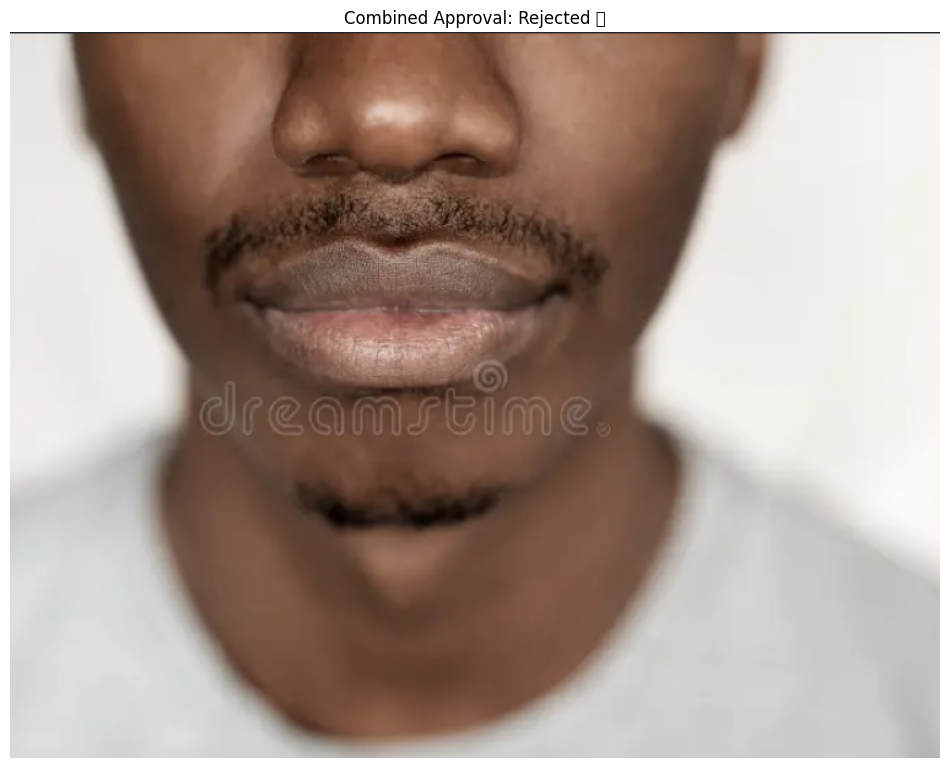

In [ ]:
def run_gun_detection_inference(image_rgb, yolov8_model_path, custom_class_names, device):
    """
    Performs gun detection inference on a given RGB image using the custom YOLOv8 model.
    Returns (is_gun_detected, detected_objects_list).
    """
    is_gun_detected = False
    detected_objects_list = []

    try:
        model = YOLO(yolov8_model_path)

        results = model.predict(
            source=image_rgb,
            conf=0.25,
            device=device,
            imgsz=640,
            save=False,
            verbose=False
        )

        for r in results:
            for box in r.boxes:
                class_id = int(box.cls[0])
                class_name = model.names[class_id]
                confidence = float(box.conf[0])
                detected_objects_list.append(f"{class_name} ({confidence:.2f})")

                if class_name in custom_class_names:
                    is_gun_detected = True
                    break
            if is_gun_detected:
                break
    except Exception as e:
        print(f"Error during gun detection inference: {e}")

    return is_gun_detected, detected_objects_list

# Helper functions for image quality checks, copied from an earlier cell
def is_blurry(image, threshold=100):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    variance = cv2.Laplacian(gray, cv2.CV_64F).var()
    return variance < threshold, variance

def is_dark(image, threshold=50):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    brightness = np.mean(gray)
    return brightness < threshold, brightness

def detect_faces(image):
    """
    Detects faces in an image using RetinaFace.
    Returns a dictionary of detected faces or an empty dictionary if none are found.
    """
    faces = RetinaFace.detect_faces(image)
    if isinstance(faces, dict):
        return faces
    else:
        return {}

def perform_combined_approval_check(yolov8_gun_model_path):
    """
    Uploads an image and runs both general image moderation (face, quality)
    and custom gun detection. Combines results for final approval/rejection.
    """
    print("\n================================================")
    print("  STARTING COMBINED IMAGE APPROVAL CHECK")
    print("================================================")

    # 1. Image Upload
    print("\nPlease upload an image for combined approval check:")
    uploaded = files.upload()

    if not uploaded:
        print("No image uploaded. Aborting check.")
        print("Decision: Not Processed (No image uploaded)")
        return

    uploaded_filename = list(uploaded.keys())[0]
    print(f"Image '{uploaded_filename}' uploaded successfully.\n")

    # 2. Read Image
    image_bgr = cv2.imread(uploaded_filename)
    if image_bgr is None:
        print(f"Error reading image: {uploaded_filename}")
        print("Decision: Rejected \u274C (Error reading image file)")
        return

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    annotated_combined = image_rgb.copy()

    final_decision = "Approved \u2705"
    all_reasons = []
    all_detected_objects = []

    # --- PART 1: General Image Moderation (Image Quality & Face Detection/Rules) ---
    print("\n--- Running General Image Moderation (Image Quality & Face Detection) ---")
    current_moderation_decision = "Approved \u2705"
    current_moderation_reasons = []
    face_count = 0

    # Image Quality Check
    height, width = image_rgb.shape[:2]
    if width < 200 or height < 200:
        current_moderation_decision = "Rejected \u274C"
        current_moderation_reasons.append("Image resolution too low.")

    blur_status, blur_score = is_blurry(image_rgb)
    if blur_status:
        current_moderation_decision = "Rejected \u274C"
        current_moderation_reasons.append(f"Image is blurry. Blur score: {blur_score:.2f}")

    dark_status, brightness = is_dark(image_rgb)
    if dark_status:
        current_moderation_decision = "Rejected \u274C"
        current_moderation_reasons.append(f"Image too dark. Brightness: {brightness:.2f}")

    # Face Detection (RetinaFace)
    faces = detect_faces(image_rgb)
    if isinstance(faces, dict):
        face_count = len(faces)
    else:
        face_count = 0

    print("Faces Detected (RetinaFace):", face_count)

    # Draw Faces on combined annotated image
    for key in faces:
        facial_area = faces[key]["facial_area"]
        x1, y1, x2, y2 = facial_area
        cv2.rectangle(annotated_combined, (x1, y1), (x2, y2), (255, 255, 0), 2) # Yellow for faces
        cv2.putText(annotated_combined, "Face", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)

    # Face Rules
    if face_count == 0:
        current_moderation_decision = "Rejected \u274C"
        current_moderation_reasons.append("No human face detected.")
    elif face_count > 1:
        current_moderation_decision = "Rejected \u274C"
        current_moderation_reasons.append(f"Multiple faces detected ({face_count}).")

    if current_moderation_decision == "Rejected \u274C":
        final_decision = "Rejected \u274C"
    all_reasons.extend([f"General Moderation: {r}" for r in current_moderation_reasons])
    print(f"General Moderation Decision: {current_moderation_decision}")

    # --- PART 2: Custom YOLOv8 Gun Detection ---
    print("\n--- Running Custom YOLOv8 Gun Detection ---")
    gun_detection_status, gun_detected_objects = run_gun_detection_inference(image_rgb, yolov8_gun_model_path, CUSTOM_CLASS_NAMES, DEVICE)

    if gun_detection_status:
        final_decision = "Rejected \u274C"
        all_reasons.append("Gun Detection: Weapon / unsafe object detected by custom model.")

    # Draw gun detection objects on combined annotated image
    if gun_detection_status:
        gun_model_loaded = YOLO(yolov8_gun_model_path)
        gun_results_for_drawing = gun_model_loaded.predict(
            source=image_rgb,
            conf=0.25,
            device=DEVICE,
            imgsz=640,
            save=False,
            verbose=False
        )
        for r in gun_results_for_drawing:
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                confidence = float(box.conf[0])
                class_name = gun_model_loaded.names[int(box.cls[0])]
                if class_name in CUSTOM_CLASS_NAMES:
                    cv2.rectangle(annotated_combined, (x1, y1), (x2, y2), (255, 0, 0), 2) # Red for guns
                    cv2.putText(annotated_combined, f"{class_name} {confidence:.2f}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    all_detected_objects.extend([f"Gun Detection: {obj}" for obj in gun_detected_objects])
    print(f"Custom Gun Detection Status: {'Rejected \u274C' if gun_detection_status else 'Approved \u2705'}")

    # --- Final Decision and Display ---
    print("\n================================================")
    print("           FINAL COMBINED RESULT")
    print("================================================")

    print("\nDecision:")
    print(final_decision)

    print("\nReasons:")
    if not all_reasons:
        all_reasons.append("No specific issues detected, image is generally acceptable.")
    for reason in all_reasons:
        print("-", reason)

    print("\nDetected Objects (all sources):")
    if not all_detected_objects:
        print("- None")
    else:
        for obj in all_detected_objects:
            print("- ", obj)

    print("\nFace Count:", face_count)

    plt.figure(figsize=(12, 10))
    plt.imshow(annotated_combined)
    plt.title(f"Combined Approval: {final_decision}")
    plt.axis("off")
    plt.show()

# Call the combined approval check function using the best_model_path
# obtained from the previous custom YOLOv8 training.
perform_combined_approval_check(best_model_path)


  STARTING COMBINED IMAGE APPROVAL CHECK

Please upload an image for combined approval check:


Saving Screenshot 2026-05-18 at 5.13.23 PM.png to Screenshot 2026-05-18 at 5.13.23 PM (8).png
Image 'Screenshot 2026-05-18 at 5.13.23 PM (8).png' uploaded successfully.


--- Running General Image Moderation (Image Quality & Face Detection) ---
Faces Detected (RetinaFace): 0
General Moderation Decision: Rejected ❌

--- Running Custom YOLOv8 Gun Detection ---
Custom Gun Detection Status: Approved ✅

           FINAL COMBINED RESULT

Decision:
Rejected ❌

Reasons:
- General Moderation: Image is blurry. Blur score: 76.82
- General Moderation: No human face detected.

Detected Objects (all sources):
- None

Face Count: 0


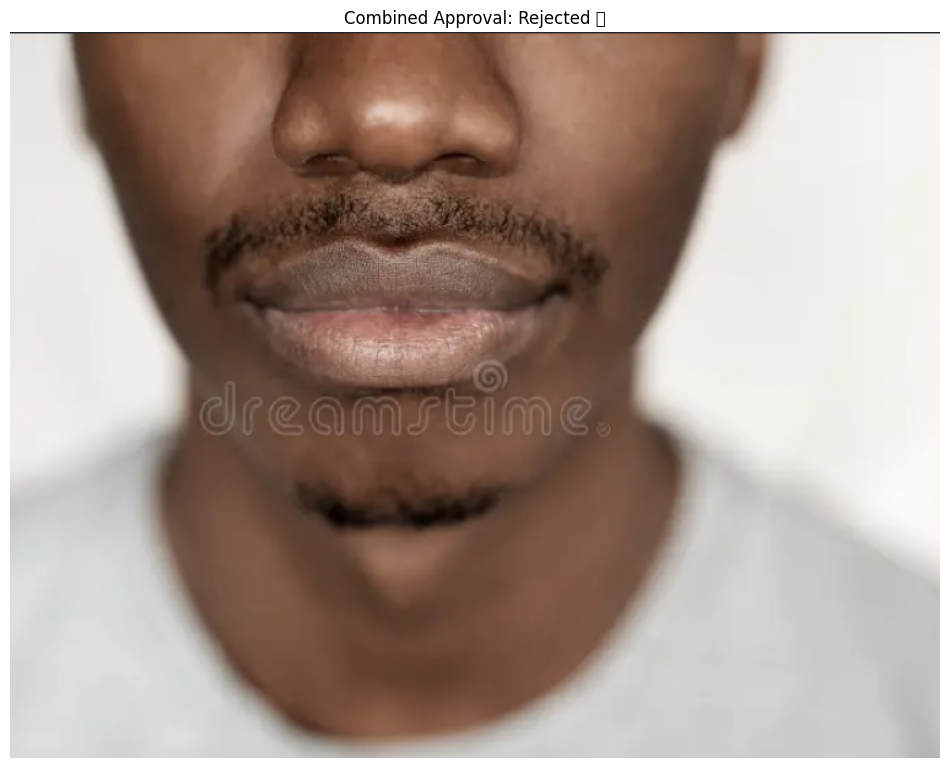

In [ ]:
perform_combined_approval_check(best_model_path)

In [ ]:
def verify_uploaded_images_for_same_person():
    """
    Uploads two images and checks if the person in both images is the same
    using DeepFace's verification functionality.
    """
    print("\n--- Starting Same Person Verification ---")

    # Upload first image
    print("\nPlease upload the FIRST image (reference image):")
    uploaded1 = files.upload()
    if not uploaded1:
        print("No first image uploaded. Aborting verification.")
        return
    img1_filename = list(uploaded1.keys())[0]
    print(f"First image '{img1_filename}' uploaded successfully.")

    # Upload second image
    print("\nPlease upload the SECOND image (image to compare):")
    uploaded2 = files.upload()
    if not uploaded2:
        print("No second image uploaded. Aborting verification.")
        # Clean up the first uploaded file if necessary
        os.remove(img1_filename)
        return
    img2_filename = list(uploaded2.keys())[0]
    print(f"Second image '{img2_filename}' uploaded successfully.")

    try:
        # Use DeepFace to verify if the faces are of the same person
        result = DeepFace.verify(
            img1_path=img1_filename,
            img2_path=img2_filename,
            enforce_detection=False # Set to True if you want to strictly enforce face detection
        )

        print("\n========================================")
        print("         VERIFICATION RESULT")
        print("========================================")

        if result["verified"]:
            print(f"Result: The persons in '{img1_filename}' and '{img2_filename}' are the SAME. ✅")
        else:
            print(f"Result: The persons in '{img1_filename}' and '{img2_filename}' are DIFFERENT. ❌")

        print(f"  Similarity Score (distance): {result['distance']:.4f}")
        print(f"  Threshold: {result['threshold']:.4f}")
        print(f"  Model: {result['model']}")
        print(f"  Detector: {result['detector_backend']}")

    except Exception as e:
        print(f"Error during face verification: {e}")
        print("Could not verify persons. Please ensure both images contain clear faces.")
    finally:
        # Clean up uploaded files
        if os.path.exists(img1_filename):
            os.remove(img1_filename)
        if os.path.exists(img2_filename):
            os.remove(img2_filename)
        print("Uploaded files cleaned up.")

    print("\n--- Same Person Verification Completed ---")

# Call the function to initiate the process
verify_uploaded_images_for_same_person()


--- Starting Same Person Verification ---

Please upload the FIRST image (reference image):


No first image uploaded. Aborting verification.
